In [1]:

from qiskit_optimization.algorithms.qrao import (
    QuantumRandomAccessEncoding,
    QuantumRandomAccessOptimizer,
    SemideterministicRounding,
)



Problem name: Max-cut

Maximize
  -2*x_0*x_1 - 2*x_0*x_3 - 2*x_0*x_4 - 2*x_1*x_2 - 2*x_1*x_5 - 2*x_2*x_3
  - 2*x_2*x_4 - 2*x_3*x_5 - 2*x_4*x_5 + 3*x_0 + 3*x_1 + 3*x_2 + 3*x_3 + 3*x_4
  + 3*x_5

Subject to
  No constraints

  Binary variables (6)
    x_0 x_1 x_2 x_3 x_4 x_5



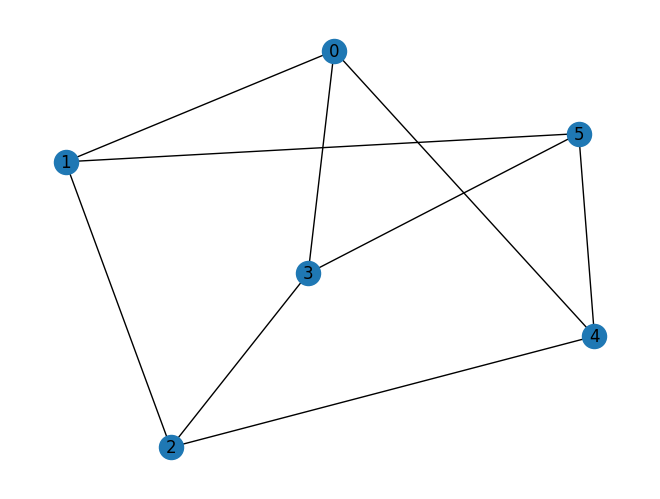

In [2]:

import networkx as nx
from qiskit_optimization.applications import Maxcut

seed = 1
num_nodes = 6
graph = nx.random_regular_graph(d=3, n=num_nodes, seed=seed)
nx.draw(graph, with_labels=True, pos=nx.spring_layout(graph, seed=seed))

maxcut = Maxcut(graph)
problem = maxcut.to_quadratic_program()
print(problem.prettyprint())



In [3]:
from qiskit_optimization.algorithms.qrao import QuantumRandomAccessEncoding

# Create an encoding object with a maximum of 3 variables per qubit, aka a (3,1,p)-QRAC
encoding = QuantumRandomAccessEncoding(max_vars_per_qubit=3)

# Encode the QUBO problem into an encoded Hamiltonian
encoding.encode(problem)

# This is our encoded Hamiltonian
print(f"Our encoded Hamiltonian is:\n( {encoding.qubit_op} ).\n")
print(
    "We achieve a compression ratio of "
    f"({encoding.num_vars} binary variables : {encoding.num_qubits} qubits) "
    f"≈ {encoding.compression_ratio}.\n"
)

Our encoded Hamiltonian is:
( SparsePauliOp(['XX', 'XY', 'XZ', 'YX', 'ZX', 'YY', 'YZ', 'ZY', 'ZZ'],
              coeffs=[1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j,
 1.5+0.j]) ).

We achieve a compression ratio of (6 binary variables : 2 qubits) ≈ 3.0.



In [5]:

from qiskit.circuit.library import real_amplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_optimization.algorithms.qrao import (
    QuantumRandomAccessOptimizer,
    SemideterministicRounding,
)
from qiskit_optimization.minimum_eigensolvers import VQE
from qiskit_optimization.optimizers import COBYLA

# Prepare the VQE algorithm
ansatz = real_amplitudes(2)
vqe = VQE(
    ansatz=ansatz,
    optimizer=COBYLA(),
    estimator=StatevectorEstimator(),
)

# Use semi-deterministic rounding, known as "Pauli rounding"
# in https://arxiv.org/pdf/2111.03167v2.pdf
# (This is the default if no rounding scheme is specified.)
semidterministic_rounding = SemideterministicRounding()

# Construct the optimizer
qrao = QuantumRandomAccessOptimizer(min_eigen_solver=vqe, rounding_scheme=semidterministic_rounding)


In [6]:
# Solve the optimization problem
results = qrao.solve(problem)

print(
    f"The objective function value: {results.fval}\n"
    f"x: {results.x}\n"
    f"relaxed function value: {-1 * results.relaxed_fval}\n"
)

The objective function value: 6.0
x: [0 1 1 1 1 0]
relaxed function value: 8.999999985229554



The obtained solution places a partition between nodes [0, 5] and nodes [1, 2, 3, 4].


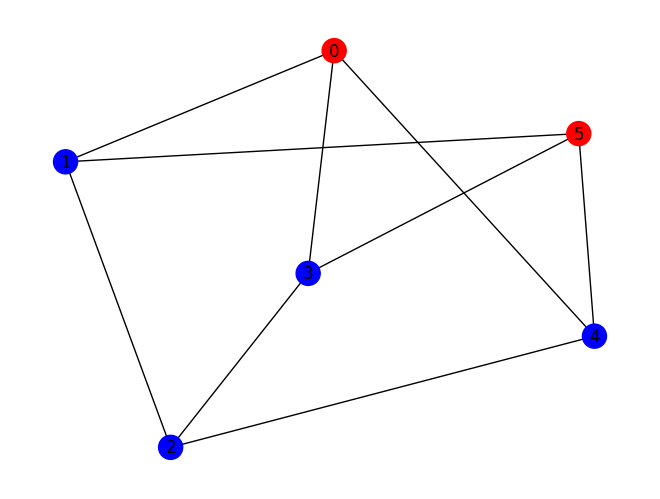

In [7]:
maxcut_partition = maxcut.interpret(results)
print(
    f"The obtained solution places a partition between nodes {maxcut_partition[0]} "
    f"and nodes {maxcut_partition[1]}."
)
maxcut.draw(results, pos=nx.spring_layout(graph, seed=seed))

In [8]:
results.relaxed_result



In [9]:
results.samples

[SolutionSample(x=array([0, 1, 1, 1, 1, 0]), fval=np.float64(6.0), probability=1.0, status=<OptimizationResultStatus.SUCCESS: 0>)]

In [10]:
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.minimum_eigensolvers import NumPyMinimumEigensolver

exact_mes = NumPyMinimumEigensolver()
exact = MinimumEigenOptimizer(exact_mes)
exact_result = exact.solve(problem)
print(exact_result.prettyprint())

objective function value: 9.0
variable values: x_0=0.0, x_1=1.0, x_2=0.0, x_3=1.0, x_4=1.0, x_5=0.0
status: SUCCESS


In [11]:
print("QRAO Approximate Optimal Function Value:", results.fval)
print("Exact Optimal Function Value:", exact_result.fval)
print(f"Approximation Ratio: {results.fval /  exact_result.fval :.2f}")

QRAO Approximate Optimal Function Value: 6.0
Exact Optimal Function Value: 9.0
Approximation Ratio: 0.67


### Magic Rounding 

In [12]:
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms.qrao import MagicRounding

estimator = StatevectorEstimator()
sampler = StatevectorSampler(seed=seed, default_shots=10000)

# Prepare the VQE algorithm
ansatz = real_amplitudes(2)
vqe = VQE(
    ansatz=ansatz,
    optimizer=COBYLA(),
    estimator=estimator,
)


# Use magic rounding
magic_rounding = MagicRounding(sampler=sampler)

# Construct the optimizer
qrao = QuantumRandomAccessOptimizer(min_eigen_solver=vqe, rounding_scheme=magic_rounding)

results = qrao.solve(problem)

In [13]:

print(
    f"The objective function value: {results.fval}\n"
    f"x: {results.x}\n"
    f"relaxed function value: {-1 * results.relaxed_fval}\n"
)



The objective function value: 9.0
x: [1 0 1 0 0 1]
relaxed function value: 8.999999997477069



In [14]:
print(f"The number of distinct samples is {len(results.samples)}.")
print("Top 10 samples with the largest fval:")
for sample in results.samples[:10]:
    print(sample)

The number of distinct samples is 56.
Top 10 samples with the largest fval:
SolutionSample(x=array([1, 0, 1, 0, 0, 1]), fval=np.float64(9.0), probability=np.float64(0.0317), status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([0, 1, 0, 1, 1, 0]), fval=np.float64(9.0), probability=np.float64(0.0336), status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1, 1, 1, 0, 0, 1]), fval=np.float64(6.0), probability=np.float64(0.0195), status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([0, 0, 0, 1, 1, 0]), fval=np.float64(6.0), probability=np.float64(0.0202), status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1, 0, 1, 1, 0, 1]), fval=np.float64(6.0), probability=np.float64(0.0195), status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([0, 1, 0, 0, 1, 0]), fval=np.float64(6.0), probability=np.float64(0.0202), status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1, 0, 1, 0, 1, 1]), fval=np.float64(

#### Manually Solving Relaxed Problem

In [15]:

# Encode the QUBO problem into a relaxed Hamiltonian
encoding = QuantumRandomAccessEncoding(max_vars_per_qubit=3)
encoding.encode(problem)

# Solve the relaxed problem
relaxed_results, rounding_context = qrao.solve_relaxed(encoding)



In [16]:
for k in dir(relaxed_results):
    if not k.startswith("_"):
        print(f"{k}: {getattr(relaxed_results, k)}")



aux_operators_evaluated: [(np.float64(-9.47596699722446e-05), {'target_precision': 0.0, 'circuit_metadata': {}}), (np.float64(9.475348752548596e-05), {'target_precision': 0.0, 'circuit_metadata': {}}), (np.float64(0.0), {'target_precision': 0.0, 'circuit_metadata': {}}), (np.float64(0.0), {'target_precision': 0.0, 'circuit_metadata': {}}), (np.float64(-7.988406153269789e-05), {'target_precision': 0.0, 'circuit_metadata': {}}), (np.float64(7.987672772447052e-05), {'target_precision': 0.0, 'circuit_metadata': {}})]
combine: <bound method AlgorithmResult.combine of <qiskit_optimization.minimum_eigensolvers.vqe.VQEResult object at 0x0000026B03AF3970>>
cost_function_evals: 98
eigenvalue: -4.4999999566214
optimal_circuit:      ┌──────────┐     ┌──────────┐     ┌──────────┐     ┌──────────┐
q_0: ┤ Ry(θ[0]) ├──■──┤ Ry(θ[2]) ├──■──┤ Ry(θ[4]) ├──■──┤ Ry(θ[6]) ├
     ├──────────┤┌─┴─┐├──────────┤┌─┴─┐├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Ry(θ[1]) ├┤ X ├┤ Ry(θ[3]) ├┤ X ├┤ Ry(θ[5]) ├┤ X ├┤ Ry(θ[7]) 

In [17]:
# Round the relaxed solution using semi-deterministic rounding
semidterministic_rounding = SemideterministicRounding()
sdr_results = semidterministic_rounding.round(rounding_context)
qrao_results_sdr = qrao.process_result(
    problem=problem, encoding=encoding, relaxed_result=relaxed_results, rounding_result=sdr_results
)

print(
    f"The objective function value: {qrao_results_sdr.fval}\n"
    f"x: {qrao_results_sdr.x}\n"
    f"relaxed function value: {-1 * qrao_results_sdr.relaxed_fval}\n"
    f"The number of distinct samples is {len(qrao_results_sdr.samples)}."
)



The objective function value: 4.0
x: [1 0 0 0 1 0]
relaxed function value: -8.9999999566214
The number of distinct samples is 1.


In [18]:
magic_rounding = MagicRounding(sampler=sampler)
mr_results = magic_rounding.round(rounding_context)
qrao_results_mr = qrao.process_result(
    problem=problem, encoding=encoding, relaxed_result=relaxed_results, rounding_result=mr_results
)

print(
    f"The objective function value: {qrao_results_mr.fval}\n"
    f"x: {qrao_results_mr.x}\n"
    f"relaxed function value: {-1 * qrao_results_mr.relaxed_fval}\n"
    f"The number of distinct samples is {len(qrao_results_mr.samples)}."
)

The objective function value: 9.0
x: [1 0 1 0 0 1]
relaxed function value: -8.9999999566214
The number of distinct samples is 56.
